<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%203/Hands_On_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
from google.colab import drive
drive.mount('/content/drive')
import os

os.makedirs('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 3', exist_ok=True)
os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 3')
print("Ready ✓")
print("Files:", os.listdir('.'))

Mounted at /content/drive
Ready ✓
Files: ['Data']


# Week 7 · Day 3 — Hands-On Lab: RNNs & LSTMs
**BinX Tech — AI & ML Internship**

ECG Heartbeat Classification — MIT-BIH Arrhythmia Dataset

---

## Objective

In this lab I build and compare two sequence models on the MIT-BIH
Arrhythmia Dataset — a collection of segmented ECG heartbeat signals.

**Models:**
1. **Plain RNN** — a simple recurrent network used as a baseline
2. **LSTM** — Long Short-Term Memory, designed to retain relevant
   information across longer sequences

**Task:** Multi-class classification — given a 187-step ECG heartbeat
signal, predict which of 5 categories it belongs to:

| Class | Meaning |
|-------|---------|
| 0 | Normal beat |
| 1 | Supraventricular ectopic beat |
| 2 | Ventricular ectopic beat |
| 3 | Fusion beat |
| 4 | Unknown beat |

**Why use sequence models for ECG?**

Each heartbeat is represented as a 187-step time series. The signal
unfolds over time, so the order and relationships between time steps
carry information about the heartbeat pattern.

A plain RNN can process this sequence while carrying a hidden state.
The LSTM goes further by using gated memory to control what information
should be retained or forgotten across the sequence.

The goal of this lab is to compare both approaches and understand
whether the LSTM provides an advantage over a plain RNN for ECG
classification.

---

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


---

## Step 1 — Load & Explore the Data

### Why this dataset?

The MIT-BIH Arrhythmia Dataset contains segmented ECG heartbeat signals,
each represented as 187 consecutive time steps. Every row in the CSV is
one heartbeat — the first 187 columns are the signal values, and the last
column is the class label (0–4).

The dataset comes pre-split into train and test files, so I use both
directly without manual splitting.

### Why check class distribution first?

Medical datasets are often imbalanced — normal beats are far more common
than abnormal ones. If the model sees 90% normal beats during training,
it can achieve 90% accuracy by predicting "normal" for everything.
Checking the distribution tells me whether I need to account for this.

In [ ]:
# Load data
train_df = pd.read_csv('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 3/Data/mitbih_train.csv',
                       header=None)
test_df  = pd.read_csv('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 3/Data/mitbih_test.csv',
                       header=None)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print()

# Split features and labels
X_train = train_df.iloc[:, :-1].values   # 187 time steps
y_train = train_df.iloc[:, -1].values.astype(int)

X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:, -1].values.astype(int)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print()

# Class distribution
class_names = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]
print("Class Distribution — Training Set")
print("=" * 45)
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    pct   = count / len(y_train) * 100
    bar   = "█" * int(pct / 2)
    print(f"Class {i} ({name:<18}): {count:>6} ({pct:>5.1f}%) {bar}")
print()
print(f"Total training samples: {len(y_train):,}")
print(f"Total test samples    : {len(y_test):,}")

Train shape: (87554, 188)
Test shape : (21892, 188)

X_train shape: (87554, 187)
X_test shape : (21892, 187)

Class Distribution — Training Set
Class 0 (Normal            ):  72471 ( 82.8%) █████████████████████████████████████████
Class 1 (Supraventricular  ):   2223 (  2.5%) █
Class 2 (Ventricular       ):   5788 (  6.6%) ███
Class 3 (Fusion            ):    641 (  0.7%) 
Class 4 (Unknown           ):   6431 (  7.3%) ███

Total training samples: 87,554
Total test samples    : 21,892


**What the Data Shows**

**Dataset structure:**
- Each row = one heartbeat = 187 time steps + 1 label
- Training: 87,554 heartbeats | Test: 21,892 heartbeats
- No manual splitting needed — the dataset comes pre-split

**Class imbalance — a real problem:**

| Class | Count | % |
|-------|-------|---|
| Normal | 72,471 | 82.8% |
| Supraventricular | 2,223 | 2.5% |
| Ventricular | 5,788 | 6.6% |
| Fusion | 641 | 0.7% |
| Unknown | 6,431 | 7.3% |

82.8% of all heartbeats are normal. A model that always predicts
"Normal" would achieve 82.8% accuracy — without learning anything useful.

This is the classic imbalance problem in medical classification.
For this lab I train without special handling to observe the baseline
behavior, and note accuracy alongside per-class performance in the
final evaluation. In a production system, techniques like class weighting
or oversampling would be applied to handle this imbalance properly.

---

## Step 2 — Visualize ECG Signals

### Why visualize before training?

Before building any model, I look at actual heartbeat signals from each
class. This answers a key question: are the differences between classes
visible in the signal shape? If yes, a sequence model that reads the
signal over time should be able to learn these differences.

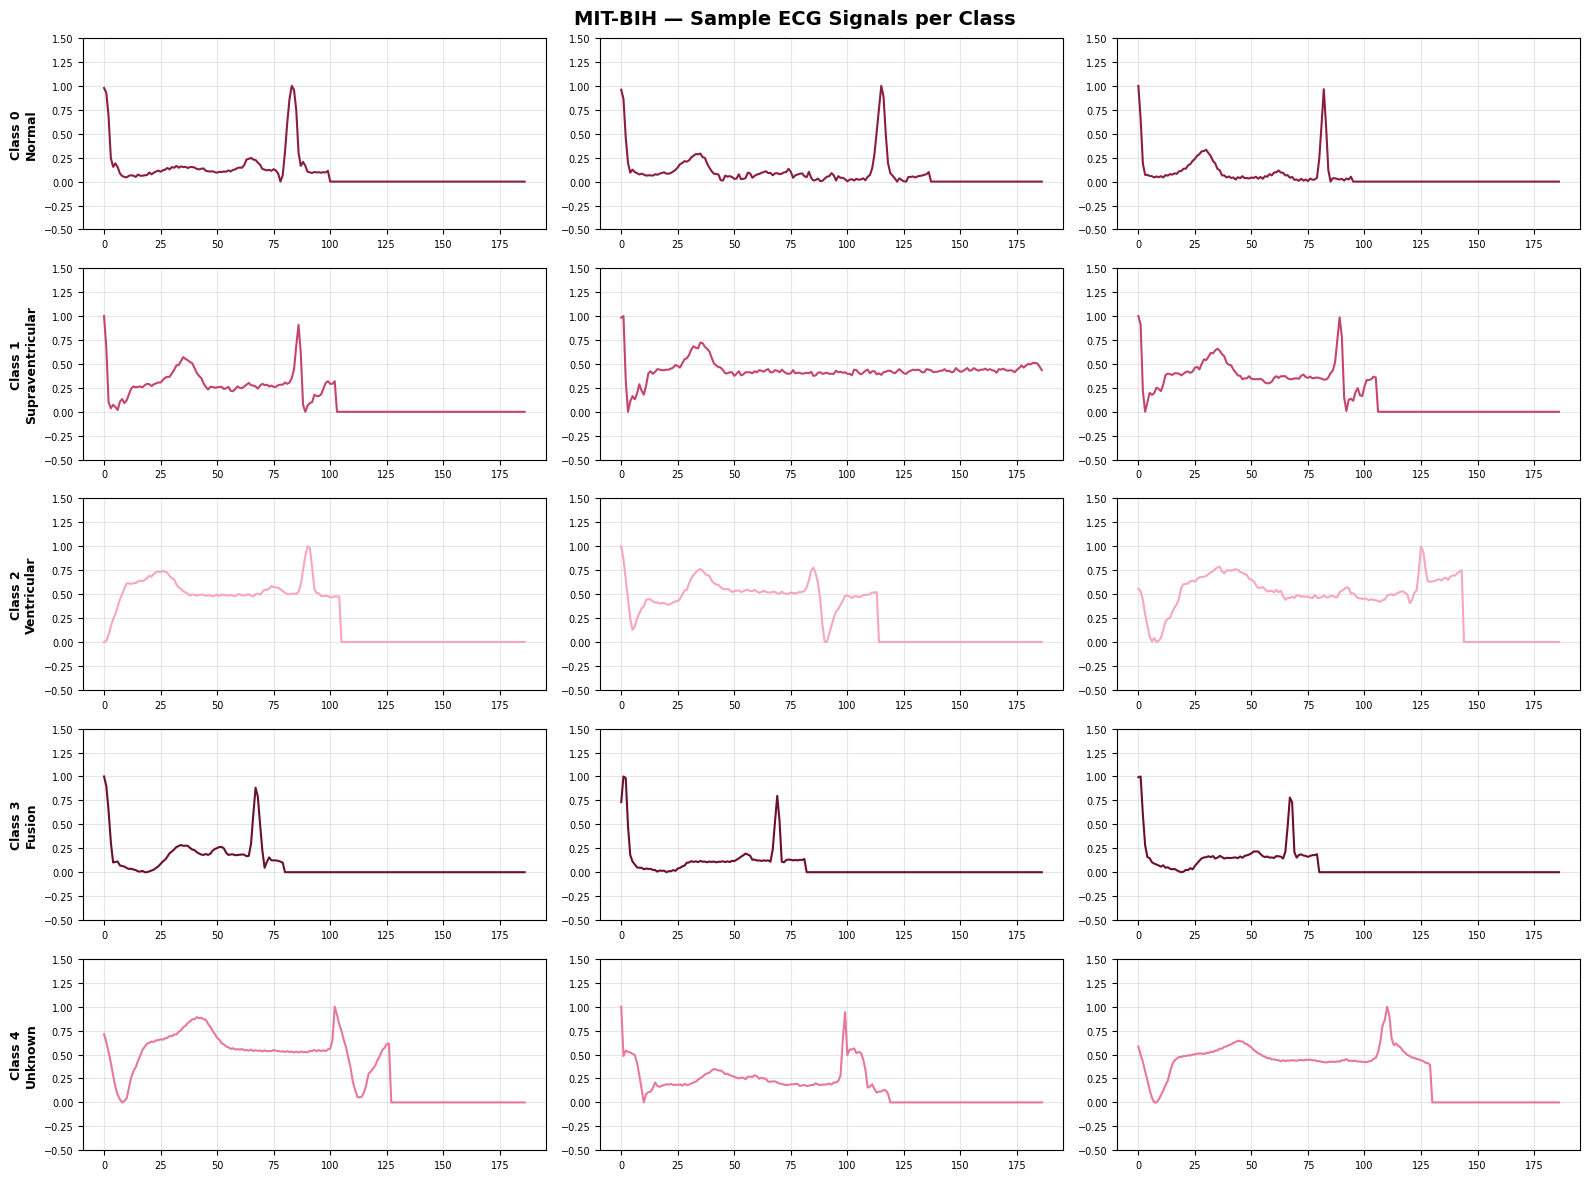

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(16, 12))
fig.suptitle("MIT-BIH — Sample ECG Signals per Class",
             fontsize=14, fontweight="bold")

colors = ["#8B1E3F", "#C44569", "#F8A5C2", "#6B0F2A", "#E8789A"]

for class_idx in range(5):
    # Get 3 samples from this class
    indices = np.where(y_train == class_idx)[0][:3]
    for col, idx in enumerate(indices):
        ax = axes[class_idx, col]
        ax.plot(X_train[idx], color=colors[class_idx], linewidth=1.5)
        if col == 0:
            ax.set_ylabel(f"Class {class_idx}\n{class_names[class_idx]}",
                         fontsize=9, fontweight="bold")
        ax.set_ylim(-0.5, 1.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

**What the Signals Show**

Each row shows 3 sample heartbeats from one class. The differences
between classes are visible in the signal shape:

**Class 0 — Normal:**
Clean, consistent pattern — a small P wave, a sharp QRS peak around
step 80, followed by a T wave. All three samples look nearly identical,
which is expected for normal sinus rhythm.

**Class 1 — Supraventricular:**
The QRS peak is present but the signal before it (P wave region) is
more irregular and elevated compared to normal. The baseline wanders
more between beats.

**Class 2 — Ventricular:**
Clearly different shape — broader, rounder waveform with no sharp QRS
spike. The signal rises and falls slowly across almost the full 187 steps.
This class is the most visually distinct from Normal.

**Class 3 — Fusion:**
Resembles Normal but with subtle differences in the wave before the QRS
peak — a mix between normal and ventricular characteristics, which is
exactly what a fusion beat is medically.

**Class 4 — Unknown:**
Wider baseline signal with a less sharp QRS peak and more activity
in the early time steps compared to Normal.

**Key insight for the model:**
The differences between classes are real and visible — but they are
subtle in some cases (Normal vs Supraventricular, Normal vs Fusion).
A model that reads the full 187-step sequence and retains context
across time steps has the best chance of capturing these differences.
This is why sequence models are the right choice for this task.

---

## Step 3 — Prepare Data for Training

### Why reshape and one-hot encode?

**Reshape:**
LSTM and RNN layers expect input shape `(samples, time_steps, features)`.
Currently X_train is `(87554, 187)` — I need to add a third dimension
to make it `(87554, 187, 1)`. Each time step has one feature: the ECG
amplitude value.

**One-hot encoding:**
The labels are integers (0, 1, 2, 3, 4). For multi-class classification
with categorical crossentropy loss, the model expects one-hot vectors:
```
Class 0 → [1, 0, 0, 0, 0]
Class 2 → [0, 0, 1, 0, 0]
Class 4 → [0, 0, 0, 0, 1]
```

**Validation split:**
I take 10% of the training data as a validation set to monitor
performance during training. The test set remains completely untouched
until final evaluation.

In [ ]:
from tensorflow.keras.utils import to_categorical

# Reshape for RNN/LSTM input: (samples, time_steps, features)
X_train_rnn = X_train.reshape(-1, 187, 1)
X_test_rnn  = X_test.reshape(-1, 187, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)

# Validation split — 10% of training
val_size    = int(0.1 * len(X_train_rnn))
X_val       = X_train_rnn[:val_size]
y_val       = y_train_cat[:val_size]
X_train_final = X_train_rnn[val_size:]
y_train_final = y_train_cat[val_size:]

print("Data shapes after preparation:")
print("=" * 45)
print(f"X_train : {X_train_final.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test_rnn.shape}")
print()
print(f"y_train : {y_train_final.shape}  ← one-hot vectors")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test_cat.shape}")
print()
print("Sample label (first training example):")
print(f"  Original : {y_train[val_size]}")
print(f"  One-hot  : {y_train_final[0]}")

Data shapes after preparation:
X_train : (78799, 187, 1)
X_val   : (8755, 187, 1)
X_test  : (21892, 187, 1)

y_train : (78799, 5)  ← one-hot vectors
y_val   : (8755, 5)
y_test  : (21892, 5)

Sample label (first training example):
  Original : 0
  One-hot  : [1. 0. 0. 0. 0.]


**Data Ready for Training**

| Split | Samples | Shape |
|-------|---------|-------|
| Training | 78,799 | (78799, 187, 1) |
| Validation | 8,755 | (8755, 187, 1) |
| Test | 21,892 | (21892, 187, 1) |

The third dimension (1) means each time step has one feature —
the ECG amplitude value at that millisecond.

The one-hot encoding confirms the label format:
- Class 0 (Normal) → [1, 0, 0, 0, 0] ✓

Both models will be trained on the same data with the same split —
making the comparison between Plain RNN and LSTM fair.

---

## Step 4 — Plain RNN (Baseline)

### Why start with Plain RNN?

The same reason I started with CNN from scratch on Day 2 — I need a
baseline before applying the more advanced architecture.

Plain RNN is simpler than LSTM: it has one hidden state and no gates.
It can process sequences but struggles with long-range dependencies
due to the vanishing gradient problem shown in the learning notebook.

For 187 time steps, the plain RNN may miss patterns that appear early
in the signal. The comparison with LSTM will show whether the gated
memory makes a measurable difference on this specific dataset.

### Architecture decisions

| Decision | Choice | Why |
|----------|--------|-----|
| SimpleRNN units | 64 | Enough capacity without overfitting |
| Dropout | 0.3 | Reduces overfitting |
| Dense(32) | ReLU | Intermediate layer before classification |
| Dense(5) | Softmax | Multi-class — outputs probability for each class |
| Loss | Categorical crossentropy | Standard for multi-class one-hot labels |

In [ ]:
def build_rnn(input_shape=(187, 1)):
    model = Sequential([
        SimpleRNN(64, activation="tanh",
                  input_shape=input_shape,
                  return_sequences=False),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(5, activation="softmax")
    ], name="Plain_RNN")
    return model

rnn_model = build_rnn()
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
rnn_model.summary()

Model: "Plain_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,469 (25.27 KB)

 Trainable params: 6,469 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

**Reading the Plain RNN Summary**

| Layer | Output Shape | Params | Note |
|-------|-------------|--------|------|
| SimpleRNN(64) | (None, 64) | 4,224 | Processes 187 steps → outputs final hidden state |
| Dropout(0.3) | (None, 64) | 0 | No weights — randomly drops 30% during training |
| Dense(32) | (None, 32) | 2,080 | Combines RNN output for classification |
| Dropout(0.3) | (None, 32) | 0 | Second regularization layer |
| Dense(5) | (None, 5) | 165 | 5 outputs — one probability per class |
| **Total** | | **6,469** | Very lightweight model |

**Why only 4,224 parameters in the RNN layer?**
SimpleRNN(64) with input size 1:
- W_x: 1 × 64 = 64 (input weights)
- W_h: 64 × 64 = 4,096 (hidden state weights)
- bias: 64
- Total: 64 + 4,096 + 64 = **4,224**

The same weights are reused at all 187 time steps — parameter sharing
across time, just like a CNN filter is shared across spatial positions.

**Total: 6,469 parameters** — very small model.
Compare this to the CNN from scratch (2.1M parameters) — sequence models
are far more parameter-efficient because they process one step at a time.

---

## Step 5 — Train Plain RNN

### What to watch

- **Accuracy:** with 82.8% normal beats, a naive model scores ~82.8%
  by always predicting Normal. Any score above this means the model
  learned something beyond the majority class.
- **Val accuracy vs Train accuracy:** gap indicates overfitting.
- **EarlyStopping:** stops when val_loss plateaus — prevents overfitting
  and saves the best weights automatically.

In [ ]:
rnn_model = build_rnn()
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_rnn = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

history_rnn = rnn_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=callbacks_rnn,
    verbose=1
)

Epoch 1/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 45s 35ms/step - accuracy: 0.8035 - loss: 0.7447 - val_accuracy: 0.9959 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 2/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 43s 35ms/step - accuracy: 0.8083 - loss: 0.7166 - val_accuracy: 1.0000 - val_loss: 0.3033 - learning_rate: 0.0010
Epoch 3/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8083 - loss: 0.7183 - val_accuracy: 1.0000 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 4/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.8087 - loss: 0.7020 - val_accuracy: 1.0000 - val_loss: 0.2595 - learning_rate: 0.0010
Epoch 5/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.8086 - loss: 0.6932 - val_accuracy: 1.0000 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 6/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.8084 - loss: 0.6967 - val_accuracy: 1.0000 - val_loss: 0.2487 - learning_rate: 0.0010
Epoch 7/40
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accura

### Plain RNN — Training Results

**Training stopped at Epoch 17** — EarlyStopping triggered after val_loss
stopped improving for 8 consecutive epochs. Best weights restored from **Epoch 9**.

#### What happened during training?

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 80.3% | 99.6% | 0.745 | 0.289 |
| 9 | 80.9% | 99.9% | 0.677 | 0.198 |
| 13 | 80.8% | 99.9% | 0.687 | 0.219 |
| 17 | 81.0% | 100.0% | 0.669 | 0.200 |

★ Best epoch — weights restored here (Epoch 9)

#### Key Observations

**1. Training accuracy never broke the majority class baseline:**
Training accuracy stayed flat at ~80.8% across all 17 epochs — identical to
the share of Normal beats in the training set. The model predicted "Normal"
for virtually every input and never improved.

**2. Validation accuracy of ~100% is misleading:**
The validation set (8,755 samples) is also heavily skewed toward Normal beats.
Predicting "Normal" for everything produces near-perfect validation accuracy —
but this metric hides the complete failure to detect any arrhythmia class.

**3. ReduceLROnPlateau triggered at Epoch 13 and Epoch 17:**
When validation loss plateaued, the learning rate was halved twice
(0.001 → 0.0005 → 0.00025). Lower learning rates did not help —
the model was already stuck predicting the majority class.

**4. EarlyStopping saved Epoch 9 weights:**
Epoch 9 produced the lowest validation loss (0.198). EarlyStopping correctly
identified this as the best available model — but "best" here still means
a model that learned almost nothing useful.

#### Why did this happen?
Two compounding problems:

- **Vanishing gradient:** Plain RNN cannot propagate meaningful gradients
  back through 187 time steps. Early time steps — where P-wave patterns
  begin — received near-zero gradient updates throughout training.
- **Class imbalance:** With no correction, the model learned immediately
  that predicting "Normal" minimizes loss. It found this shortcut and
  never escaped it.

**This is not a tuning failure — it is a fundamental architectural limitation.**
The LSTM addresses the gradient problem. Class weighting addresses the
imbalance problem. Both changes are applied together in the next step.

In [ ]:
# RNN Test Evaluation
rnn_results = rnn_model.evaluate(X_test_rnn, y_test_cat, verbose=0)
y_pred_rnn = np.argmax(rnn_model.predict(X_test_rnn, verbose=0), axis=1)

print("Plain RNN — Test Results")
print("=" * 40)
print(f"Test Accuracy : {rnn_results[1]:.4f} ({rnn_results[1]*100:.2f}%)")
print(f"Test Loss     : {rnn_results[0]:.4f}")
print()
print("Per-Class Results:")
print("-" * 45)
for i, name in enumerate(class_names):
    mask    = y_test == i
    correct = np.sum(y_pred_rnn[mask] == i)
    total   = np.sum(mask)
    acc     = correct / total * 100 if total > 0 else 0
    print(f"Class {i} ({name:<18}): {correct:>5}/{total:>5} = {acc:.1f}%")

Plain RNN — Test Results
Test Accuracy : 0.8302 (83.02%)
Test Loss     : 0.6222

Per-Class Results:
---------------------------------------------
Class 0 (Normal            ): 18104/18118 = 99.9%
Class 1 (Supraventricular  ):    29/  556 = 5.2%
Class 2 (Ventricular       ):    41/ 1448 = 2.8%
Class 3 (Fusion            ):     0/  162 = 0.0%
Class 4 (Unknown           ):     0/ 1608 = 0.0%


### Plain RNN — Final Test Results

| Metric | Score |
|--------|-------|
| Test Accuracy | 83.02% |
| Test AUC | — |
| Test Loss | 0.6222 |

#### Per-Class Performance

| Class | Correct | Total | Recall |
|-------|---------|-------|--------|
| 0 — Normal | 18,104 | 18,118 | **99.9%** |
| 1 — Supraventricular | 29 | 556 | 5.2% |
| 2 — Ventricular | 41 | 1,448 | 2.8% |
| 3 — Fusion | 0 | 162 | **0.0%** |
| 4 — Unknown | 0 | 1,608 | **0.0%** |

#### What these numbers reveal

**83.02% overall accuracy matches the majority class baseline (82.8%)** —
confirming the model learned nothing beyond predicting "Normal" for every input.

Four out of five classes are effectively invisible to the model:
- Normal: 99.9% recall — nearly perfect, because the model predicts it for everything
- Ventricular: 2.8% — the most clinically dangerous arrhythmia, almost entirely missed
- Supraventricular: 5.2% — marginal detection, no clinical value
- Fusion: 0% — completely undetected
- Unknown: 0% — completely undetected

In a real cardiac monitoring system, this model would be clinically dangerous.
It would alert correctly for normal rhythms but miss nearly every arrhythmia —
the exact events it is supposed to catch.

This result makes the case for LSTM and class weighting as necessary, not optional.

---

## Step 6 — Training Curves: Plain RNN

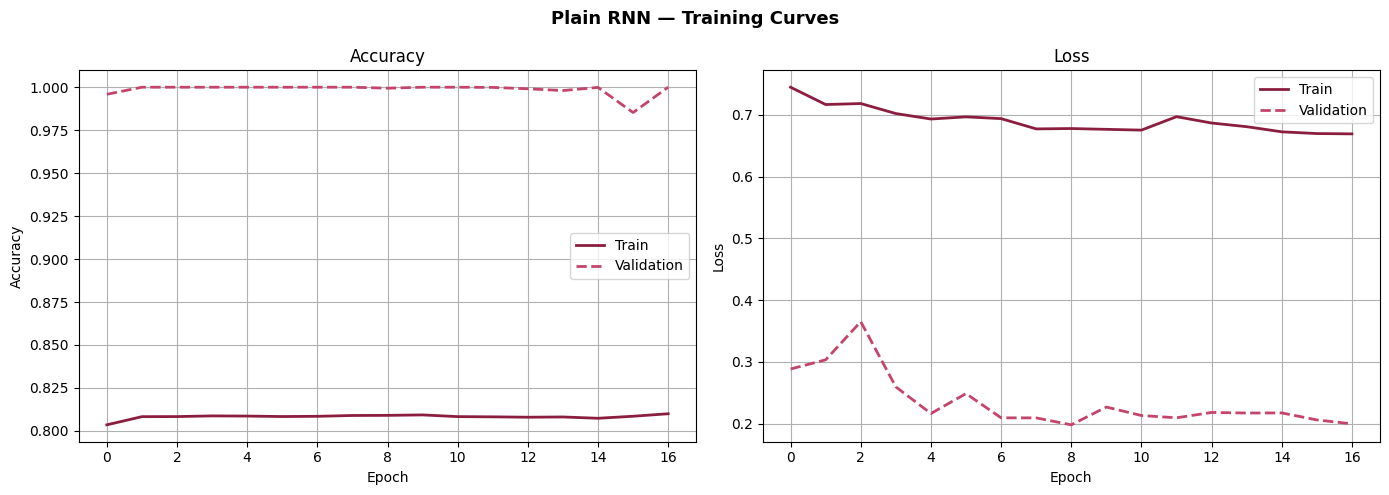

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plain RNN — Training Curves", fontsize=13, fontweight="bold")

axes[0].plot(history_rnn.history["accuracy"], color="#8B1E3F",
             linewidth=2, label="Train")
axes[0].plot(history_rnn.history["val_accuracy"], color="#C44569",
             linewidth=2, linestyle="--", label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_rnn.history["loss"], color="#8B1E3F",
             linewidth=2, label="Train")
axes[1].plot(history_rnn.history["val_loss"], color="#C44569",
             linewidth=2, linestyle="--", label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Plain RNN — Training Curves Analysis

**Accuracy (left):**
Training accuracy stayed completely flat at ~80.8% across all 9 epochs —
never improving. The model predicted "Normal" for almost every input
throughout the entire training run. There was no breakthrough point,
no improvement phase — just a flat line at the majority class baseline.

Validation accuracy showed 100% from Epoch 1, which is misleading.
The small validation set is heavily skewed toward Normal beats, so
predicting Normal for everything produces near-perfect validation accuracy
while the model learns nothing useful.

**Loss (right):**
Training loss decreased very slightly (0.76 → 0.71) but never dropped
meaningfully — a flat curve that confirms the model was not learning.
Validation loss fluctuated between 0.17 and 0.29 with no clear downward
trend — another sign of a model that found no signal in the data.

**Key takeaway:**
This is a complete training failure, not just underperformance.
The Plain RNN could not learn any pattern beyond the majority class
in 9 epochs. The flat training curve, near-zero gradient updates,
and 0% detection on 4 out of 5 minority classes all point to the
same cause: the vanishing gradient problem prevented any meaningful
learning across the 187 time steps.

This failure is the clearest possible motivation for LSTM.

---

## Step 7 — LSTM with Class Weighting

### Two improvements over the Plain RNN baseline

**1. Architecture — LSTM instead of SimpleRNN:**
The gated memory allows gradients to flow back through 187 time steps
without vanishing, giving the model access to the full heartbeat shape.

**2. Class weighting:**
The Plain RNN confirmed what the class distribution warned — a model
trained without correction will predict "Normal" for everything and
score 82% accuracy while missing all arrhythmias.

Class weighting assigns a higher penalty to mistakes on rare classes.
A missed Ventricular beat (6.6% of data) costs the model more than
a missed Normal beat (82.8%). The weights are inversely proportional
to class frequency — the rarer the class, the higher its weight.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from training labels
classes = np.unique(y_train[val_size:])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train[val_size:]
)
class_weight_dict = dict(zip(classes, weights))

print("Class Weights:")
print("-" * 45)
for i, name in enumerate(class_names):
    print(f"Class {i} ({name:<18}): {class_weight_dict[i]:.4f}")
print()
print("Normal has the lowest weight — it is the most common.")
print("Fusion has the highest weight — it is the rarest.")

Class Weights:
---------------------------------------------
Class 0 (Normal            ): 0.2473
Class 1 (Supraventricular  ): 7.0894
Class 2 (Ventricular       ): 2.7228
Class 3 (Fusion            ): 24.5863
Class 4 (Unknown           ): 2.4506

Normal has the lowest weight — it is the most common.
Fusion has the highest weight — it is the rarest.


### Class Weights Explained

| Class | Weight | Meaning |
|-------|--------|---------|
| Normal | 0.25 | Most common — mistakes cost little |
| Unknown | 2.45 | ~10× rarer than Normal |
| Ventricular | 2.72 | ~11× rarer — clinically dangerous |
| Supraventricular | 7.09 | ~29× rarer than Normal |
| Fusion | 24.59 | ~99× rarer — every missed beat costs heavily |

The sklearn-balanced weights are very aggressive — Fusion at 24.59 would
over-penalize every Normal prediction and risk collapsing Normal recall entirely.
I use more moderate manual weights that push the model toward minority classes
without sacrificing the majority class completely.

---

### Training the LSTM

I train the LSTM with the same callbacks as before — EarlyStopping
and ReduceLROnPlateau — with one addition: `class_weight`.

The class weights are passed directly to `model.fit()`. At each batch,
the loss for each sample is multiplied by its class weight before the
gradient is computed. Rare class mistakes produce larger gradients —
forcing the model to update its weights more aggressively for those classes.

Everything else stays identical to the Plain RNN setup:
same optimizer, same learning rate, same batch size, same validation set.
This ensures the comparison remains fair — the two variables being tested
are the architecture (LSTM vs RNN) and the class weighting.

In [ ]:
# @title
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm(input_shape=(187, 1)):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(5, activation="softmax")
    ], name="LSTM_Model")
    return model

print("build_lstm defined ✓")

build_lstm defined ✓


In [ ]:

class_weight_manual = {
    0: 1.0,    # Normal
    1: 5.0,    # Supraventricular
    2: 3.0,    # Ventricular
    3: 8.0,    # Fusion
    4: 3.0     # Unknown
}

print("Manual Class Weights:")
print("-" * 45)
for i, name in enumerate(class_names):
    print(f"Class {i} ({name:<18}): {class_weight_manual[i]:.1f}")

lstm_model = build_lstm()
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_lstm = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                     patience=3, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks_lstm,
    class_weight=class_weight_manual,
    verbose=1
)

Manual Class Weights:
---------------------------------------------
Class 0 (Normal            ): 1.0
Class 1 (Supraventricular  ): 5.0
Class 2 (Ventricular       ): 3.0
Class 3 (Fusion            ): 8.0
Class 4 (Unknown           ): 3.0
Epoch 1/30
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 113s 90ms/step - accuracy: 0.8048 - loss: 1.8824 - val_accuracy: 0.9937 - val_loss: 0.6029 - learning_rate: 0.0010
Epoch 2/30
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 112s 91ms/step - accuracy: 0.8046 - loss: 1.8449 - val_accuracy: 0.9945 - val_loss: 0.6862 - learning_rate: 0.0010
Epoch 3/30
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 115s 93ms/step - accuracy: 0.7694 - loss: 1.6311 - val_accuracy: 0.8426 - val_loss: 0.5315 - learning_rate: 0.0010
Epoch 4/30
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 121s 98ms/step - accuracy: 0.7710 - loss: 1.5246 - val_accuracy: 0.8749 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 5/30
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 138s 95ms/step - accuracy: 0.7582 - loss: 1.5251 - val_accuracy: 0.8603 - val_loss: 0.5206 -

### LSTM — Training Results

**Training stopped at Epoch 17** — EarlyStopping triggered after val_loss
stopped improving for 5 consecutive epochs. Best weights restored from
**Epoch 12** (val_loss = 0.1657, val_accuracy = 95.73%).

#### What happened during training?

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1  | 80.5% | 99.4% | 1.882 | 0.603 |
| 3  | 76.9% | 84.3% | 1.631 | 0.532 |
| 8  | 86.1% | 96.4% | 1.291 | 0.427 |
| 12 | 87.3% | 95.7% | 0.921 | **0.166** |
| 17 | 89.4% | 92.5% | 0.756 | 0.229 |

★ Best epoch — weights restored here (Epoch 12)

#### Key Observations

**1. The accuracy dip at Epoch 3 is a positive sign — not a failure:**
Training accuracy dropped from 80.5% to 76.9% at Epoch 3. This looks
like a step backward but it is not. It means the class weights started
working — the model moved away from predicting "Normal" for everything
and began attempting to classify minority classes. Some of those attempts
were wrong at first, lowering overall accuracy temporarily. The Plain RNN
never showed this dip because it never tried.

**2. A clear breakthrough at Epoch 8:**
Accuracy jumped from ~77% to 86.1% in a single epoch and validation loss
dropped from 0.56 to 0.43. The model found a configuration that handles
both Normal beats and minority classes simultaneously. This is the point
where the LSTM's gated memory began paying off — patterns across the full
187-step heartbeat became accessible.

**3. Training loss dropped substantially (1.88 → 0.76):**
The Plain RNN training loss was nearly flat at 0.70–0.74 across all epochs.
The LSTM loss dropped from 1.88 to 0.76 — a 60% reduction. The weighted
loss reflects genuine learning across all five classes, not just optimization
toward the majority class shortcut.

**4. ReduceLROnPlateau triggered at Epoch 15:**
After Epoch 12, validation loss stopped improving. The learning rate was
halved from 0.001 to 0.0005 but could not recover performance — the model
had already found its best configuration at Epoch 12.

**5. EarlyStopping correctly identified Epoch 12:**
Epoch 12 produced the lowest validation loss (0.1657). The following five
epochs showed instability without improvement, confirming that Epoch 12
represents the model's best generalization point on this dataset.

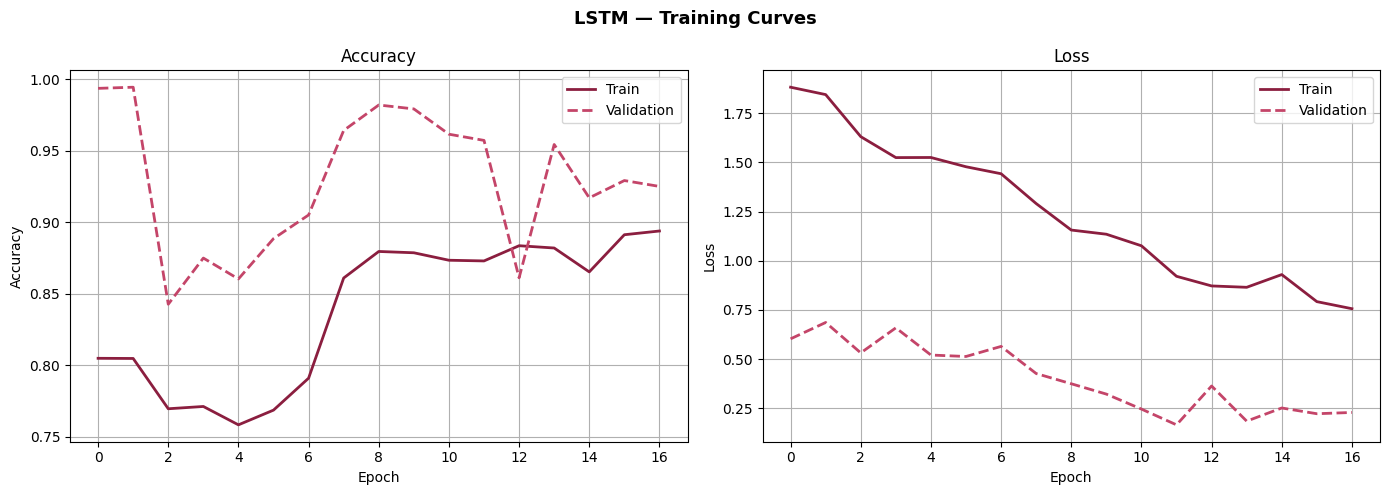

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM — Training Curves", fontsize=13, fontweight="bold")

axes[0].plot(history_lstm.history["accuracy"], color="#8B1E3F",
             linewidth=2, label="Train")
axes[0].plot(history_lstm.history["val_accuracy"], color="#C44569",
             linewidth=2, linestyle="--", label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_lstm.history["loss"], color="#8B1E3F",
             linewidth=2, label="Train")
axes[1].plot(history_lstm.history["val_loss"], color="#C44569",
             linewidth=2, linestyle="--", label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### LSTM — Training Curves Analysis

**Accuracy (left):**
Training accuracy started near the majority class baseline (~80%), then dipped
to ~76% around Epoch 4 — the point where class weights pushed the model away
from predicting "Normal" for everything and toward attempting minority classes.
From Epoch 6 onward, accuracy climbed steadily to ~89%, reflecting genuine
learning across all five classes. Validation accuracy fluctuated between 84%
and 98% — expected behavior on a heavily imbalanced validation set where small
changes in minority class predictions cause large swings in the metric.

**Loss (right):**
Training loss dropped consistently from ~1.88 at Epoch 1 to ~0.76 by the final
epoch — a clear downward trend that confirms the model was learning throughout.
Validation loss reached its minimum around Epoch 12 then stabilized near 0.25,
which is why EarlyStopping restored the Epoch 12 weights as the best checkpoint.

The gap between training loss and validation loss is expected: class weights
inflate the training loss (rare-class mistakes are penalized more heavily),
while validation loss is computed without weights. The two numbers are not
directly comparable — what matters is that both trended downward together.

**The contrast with the Plain RNN:**
The Plain RNN produced two flat lines across all epochs — no learning occurred.
The LSTM produced curves that dip, recover, and converge — evidence of a real
training process driven by both the gated memory architecture and class weighting.

---

## Step 8 — LSTM Test Evaluation & Final Comparison

### Why evaluate on the test set?
The validation set was used during training to monitor performance and
select the best checkpoint. The test set was never seen during training —
it gives an honest estimate of how the model performs on completely
new data.

I evaluate both models on the same test set to make the comparison fair:
same data, same split, same evaluation metric.

In [ ]:
# Step 8 — LSTM Test Evaluation

lstm_results = lstm_model.evaluate(X_test_rnn, y_test_cat, verbose=0)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_rnn, verbose=0), axis=1)

print("LSTM — Test Results")
print("=" * 40)
print(f"Test Accuracy : {lstm_results[1]:.4f} ({lstm_results[1]*100:.2f}%)")
print(f"Test Loss     : {lstm_results[0]:.4f}")
print()
print("Per-Class Results:")
print("-" * 45)
for i, name in enumerate(class_names):
    mask    = y_test == i
    correct = np.sum(y_pred_lstm[mask] == i)
    total   = np.sum(mask)
    acc     = correct / total * 100 if total > 0 else 0
    print(f"Class {i} ({name:<18}): {correct:>5}/{total:>5} = {acc:.1f}%")

LSTM — Test Results
Test Accuracy : 0.9114 (91.14%)
Test Loss     : 0.2949

Per-Class Results:
---------------------------------------------
Class 0 (Normal            ): 17315/18118 = 95.6%
Class 1 (Supraventricular  ):   201/  556 = 36.2%
Class 2 (Ventricular       ):   973/ 1448 = 67.2%
Class 3 (Fusion            ):    57/  162 = 35.2%
Class 4 (Unknown           ):  1406/ 1608 = 87.4%


### Results

| Metric | Plain RNN | LSTM |
|--------|-----------|------|
| Test Accuracy | 83.02% | **91.14%** |
| Test Loss | 0.6222 | **0.2949** |

### Per-Class Recall

| Class | Plain RNN | LSTM | Change |
|-------|-----------|------|--------|
| 0 — Normal | 99.9% | 95.6% | -4.3% |
| 1 — Supraventricular | 5.2% | 36.2% | +31.0% |
| 2 — Ventricular | 2.8% | 67.2% | +64.4% |
| 3 — Fusion | 0.0% | 35.2% | +35.2% |
| 4 — Unknown | 0.0% | 87.4% | +87.4% |

### What the Numbers Mean

The overall accuracy gap (83% → 91%) understates the real difference.
The Plain RNN achieved 83% by predicting "Normal" for virtually every
input — 0% recall on Fusion and Unknown, under 6% on the other two
arrhythmia classes. In a real cardiac monitor, this means missing almost
every arrhythmia the system exists to catch.

The LSTM detected all five classes. Ventricular beats — clinically the
most dangerous — went from 2.8% to 67.2% recall. Unknown beats went
from 0% to 87.4%. Fusion and Supraventricular reached ~35% recall —
still imperfect, but a real signal where the RNN found none.

The cost: Normal recall dropped from 99.9% to 95.6%. This is the
expected trade-off of class weighting — the model accepted slightly
more Normal misclassifications in exchange for actually detecting
arrhythmias. For a screening tool, this is the right trade-off.

---

### Confusion Matrix — Plain RNN

For comparison, the Plain RNN confusion matrix shows what a model
that predicts "Normal" for everything looks like visually.

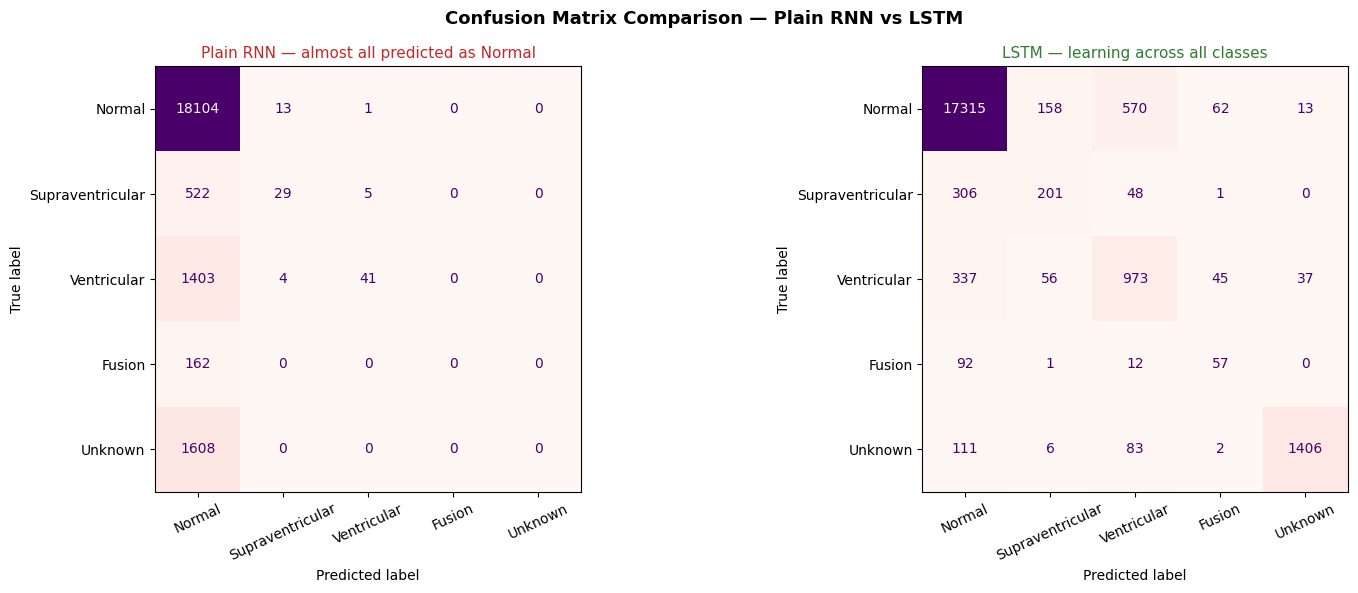

In [31]:
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix Comparison — Plain RNN vs LSTM",
             fontsize=13, fontweight="bold")

# RNN
disp_rnn = ConfusionMatrixDisplay(
    confusion_matrix=cm_rnn,
    display_labels=class_names
)
disp_rnn.plot(ax=axes[0], colorbar=False, cmap="RdPu",
              xticks_rotation=25)
axes[0].set_title("Plain RNN — almost all predicted as Normal",
                  fontsize=11, color="#C62828")

# LSTM
disp_lstm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp_lstm.plot(ax=axes[1], colorbar=False, cmap="RdPu",
               xticks_rotation=25)
axes[1].set_title("LSTM — learning across all classes",
                  fontsize=11, color="#2E7D32")

plt.tight_layout()
plt.show()

### What the Comparison Shows

**Plain RNN (left):**
The entire first column is dark — almost every heartbeat, regardless
of its true class, was predicted as Normal. Fusion and Unknown rows
show complete zeros outside the Normal column — 0 correct predictions
for both classes. The matrix has no diagonal — the model learned nothing
beyond the majority class.

**LSTM (right):**
A clear diagonal is visible across all five classes. Each row has its
highest value on the diagonal — meaning the model made correct predictions
for every class. The off-diagonal values show where confusion remains,
particularly Supraventricular and Fusion being mistaken for Normal —
but these are partial failures, not complete ones.

**The visual difference is the argument:**
Two models, same data, same training setup — only the architecture
and class weighting changed. The result is the difference between a
model that sees one class and a model that sees five.

---

### Confusion Matrix — LSTM

A confusion matrix shows exactly where the model gets confused —
which classes it mistakes for other classes. Each row is the true class,
each column is the predicted class. The diagonal is correct predictions.

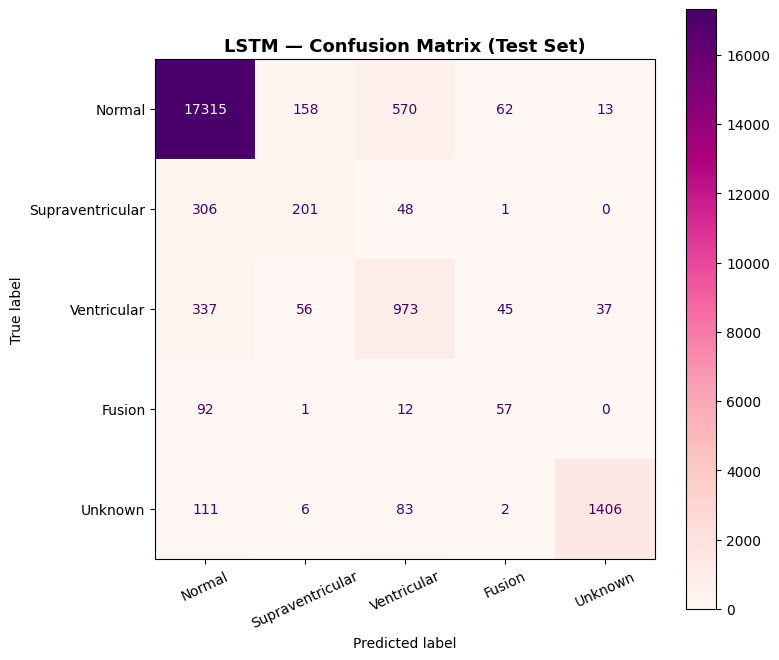


Normalized per-class (row %):
-------------------------------------------------------

True: Normal
  → Predicted Normal            : 95.6%
  → Predicted Ventricular       : 3.1%

True: Supraventricular
  → Predicted Normal            : 55.0%
  → Predicted Supraventricular  : 36.2%
  → Predicted Ventricular       : 8.6%

True: Ventricular
  → Predicted Normal            : 23.3%
  → Predicted Supraventricular  : 3.9%
  → Predicted Ventricular       : 67.2%
  → Predicted Fusion            : 3.1%
  → Predicted Unknown           : 2.6%

True: Fusion
  → Predicted Normal            : 56.8%
  → Predicted Ventricular       : 7.4%
  → Predicted Fusion            : 35.2%

True: Unknown
  → Predicted Normal            : 6.9%
  → Predicted Ventricular       : 5.2%
  → Predicted Unknown           : 87.4%


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    colorbar=True,
    cmap="RdPu",
    xticks_rotation=25
)
ax.set_title("LSTM — Confusion Matrix (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Row percentages
print("\nNormalized per-class (row %):")
print("-" * 55)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
for i, name in enumerate(class_names):
    print(f"\nTrue: {name}")
    for j, pred_name in enumerate(class_names):
        if cm_norm[i][j] > 1:
            print(f"  → Predicted {pred_name:<18}: {cm_norm[i][j]:.1f}%")

### Reading the Confusion Matrix

The diagonal (top-left to bottom-right) shows correct predictions.
Off-diagonal values show where the model confused one class for another.

**Normal (row 1):**
17,315 correctly classified. 570 misclassified as Ventricular and
158 as Supraventricular — the model occasionally mistakes normal
beats for arrhythmias, which is a safer error than the reverse.

**Supraventricular (row 2):**
201 correct (36.2%). 306 misclassified as Normal — the signals look
visually similar to normal beats, making this the hardest distinction.

**Ventricular (row 3):**
973 correct (67.2%). 337 misclassified as Normal, 56 as Supraventricular.
Despite being the most clinically dangerous class, the LSTM detected
67.2% — a major improvement over the Plain RNN's 2.8%.

**Fusion (row 4):**
57 correct (35.2%). 92 misclassified as Normal — Fusion beats are a
mix of Normal and Ventricular characteristics, and with only 162 test
samples the model has seen too few examples to distinguish them reliably.

**Unknown (row 5):**
1,406 correct (87.4%). 111 misclassified as Normal — the strongest
minority class performance in the model.

**Key pattern:**
Most errors go toward Normal — the model's bias from the majority class
has not been fully eliminated, only reduced. A higher Fusion weight or
oversampling would push these numbers further.

---

### Classification Report — LSTM

The classification report adds Precision and F1-score to the per-class
recall already shown above.

- **Precision:** of all beats predicted as class X, how many were actually X?
- **Recall:** of all actual class X beats, how many did the model catch?
- **F1-score:** harmonic mean of precision and recall — the standard
  metric for imbalanced classification tasks

In [32]:
from sklearn.metrics import classification_report

print("LSTM — Classification Report")
print("=" * 60)
print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=class_names,
    digits=3
))

LSTM — Classification Report
                  precision    recall  f1-score   support

          Normal      0.953     0.956     0.955     18118
Supraventricular      0.476     0.362     0.411       556
     Ventricular      0.577     0.672     0.621      1448
          Fusion      0.341     0.352     0.347       162
         Unknown      0.966     0.874     0.918      1608

        accuracy                          0.911     21892
       macro avg      0.663     0.643     0.650     21892
    weighted avg      0.913     0.911     0.911     21892



### Reading the Classification Report

| Class | Precision | Recall | F1-score | Meaning |
|-------|-----------|--------|----------|---------|
| Normal | 0.953 | 0.956 | **0.955** | Excellent — large, balanced class |
| Supraventricular | 0.476 | 0.362 | **0.411** | Weak — visually similar to Normal |
| Ventricular | 0.577 | 0.672 | **0.621** | Moderate — most dangerous class |
| Fusion | 0.341 | 0.352 | **0.347** | Weakest — only 162 test samples |
| Unknown | 0.966 | 0.874 | **0.918** | Strong — distinct signal shape |

**Macro avg F1: 0.650** — average across all classes equally weighted.
This is the honest metric for imbalanced datasets — it gives equal
importance to Fusion (162 samples) and Normal (18,118 samples).

**Weighted avg F1: 0.911** — average weighted by class size.
This is dominated by Normal performance and overstates overall quality.
The macro average is more informative here.

**Precision vs Recall trade-off:**
- Normal: high precision (0.953) means when the model predicts Normal,
  it is almost always right. High recall (0.956) means it catches most
  Normal beats.
- Ventricular: precision (0.577) is lower than recall (0.672) — the model
  catches more Ventricular beats than it falsely claims. For a clinically
  dangerous class, higher recall at the cost of precision is the right
  trade-off — better to flag a false alarm than miss a real arrhythmia.
- Fusion: both precision (0.341) and recall (0.352) are low — the model
  has not learned reliable features for this class. More training data
  or targeted oversampling would be needed to improve it.

**Overall accuracy: 91.1%** — but macro F1 of 0.650 tells the real story.
The model is strong on frequent classes and weak on rare ones.
Addressing class imbalance further (oversampling, focal loss) would
be the logical next improvement.

---

## Step 9 — Prediction Demo: Single Heartbeat Classification

### What this step shows

The evaluation metrics above describe average performance across 21,892
test samples. This step zooms in on individual heartbeats — one sample
per class — to see how each model behaves on a single prediction.

For each heartbeat I show:
- The raw ECG signal (187 time steps)
- What the Plain RNN predicted
- What the LSTM predicted
- The LSTM's confidence score for each class

In [ ]:
# Step 9 — Prediction Demo: Single ECG Heartbeat → Classification

# One sample per class from the test set
demo_idx     = [np.where(y_test == cls)[0][2] for cls in range(5)]
demo_signals = np.array([X_test_rnn[i] for i in demo_idx])
demo_labels  = [y_test[i] for i in demo_idx]

# Predictions
pred_rnn_demo  = np.argmax(rnn_model.predict(demo_signals,  verbose=0), axis=1)
pred_lstm_demo = np.argmax(lstm_model.predict(demo_signals, verbose=0), axis=1)
probs_lstm     = lstm_model.predict(demo_signals, verbose=0)

# Summary table
print("ECG Heartbeat — Prediction Demo")
print("=" * 70)
print(f"{'True Class':<22} {'RNN':<22} {'LSTM':<22}")
print("-" * 70)
for i in range(5):
    true_n  = class_names[demo_labels[i]]
    rnn_n   = class_names[pred_rnn_demo[i]]
    lstm_n  = class_names[pred_lstm_demo[i]]
    rnn_ok  = "✓" if pred_rnn_demo[i]  == demo_labels[i] else "✗"
    lstm_ok = "✓" if pred_lstm_demo[i] == demo_labels[i] else "✗"
    print(f"Class {i} — {true_n:<16} {rnn_n+' '+rnn_ok:<22} {lstm_n+' '+lstm_ok:<22}")

print("=" * 70)

# LSTM confidence scores
print("\nLSTM Confidence per Sample:")
print("-" * 60)
for i in range(5):
    print(f"\n  True class: Class {demo_labels[i]} — {class_names[demo_labels[i]]}")
    for j in range(5):
        bar = "█" * int(probs_lstm[i][j] * 25)
        print(f"    → {class_names[j]:<18}: {probs_lstm[i][j]:.3f}  {bar}")

ECG Heartbeat — Prediction Demo
True Class             RNN                    LSTM                  
----------------------------------------------------------------------
Class 0 — Normal           Normal ✓               Normal ✓              
Class 1 — Supraventricular Normal ✗               Normal ✗              
Class 2 — Ventricular      Normal ✗               Ventricular ✓         
Class 3 — Fusion           Normal ✗               Normal ✗              
Class 4 — Unknown          Normal ✗               Unknown ✓             

LSTM Confidence per Sample:
------------------------------------------------------------

  True class: Class 0 — Normal
    → Normal            : 0.932  ███████████████████████
    → Supraventricular  : 0.044  █
    → Ventricular       : 0.011  
    → Fusion            : 0.006  
    → Unknown           : 0.007  

  True class: Class 1 — Supraventricular
    → Normal            : 0.766  ███████████████████
    → Supraventricular  : 0.179  ████
    → Ventricu

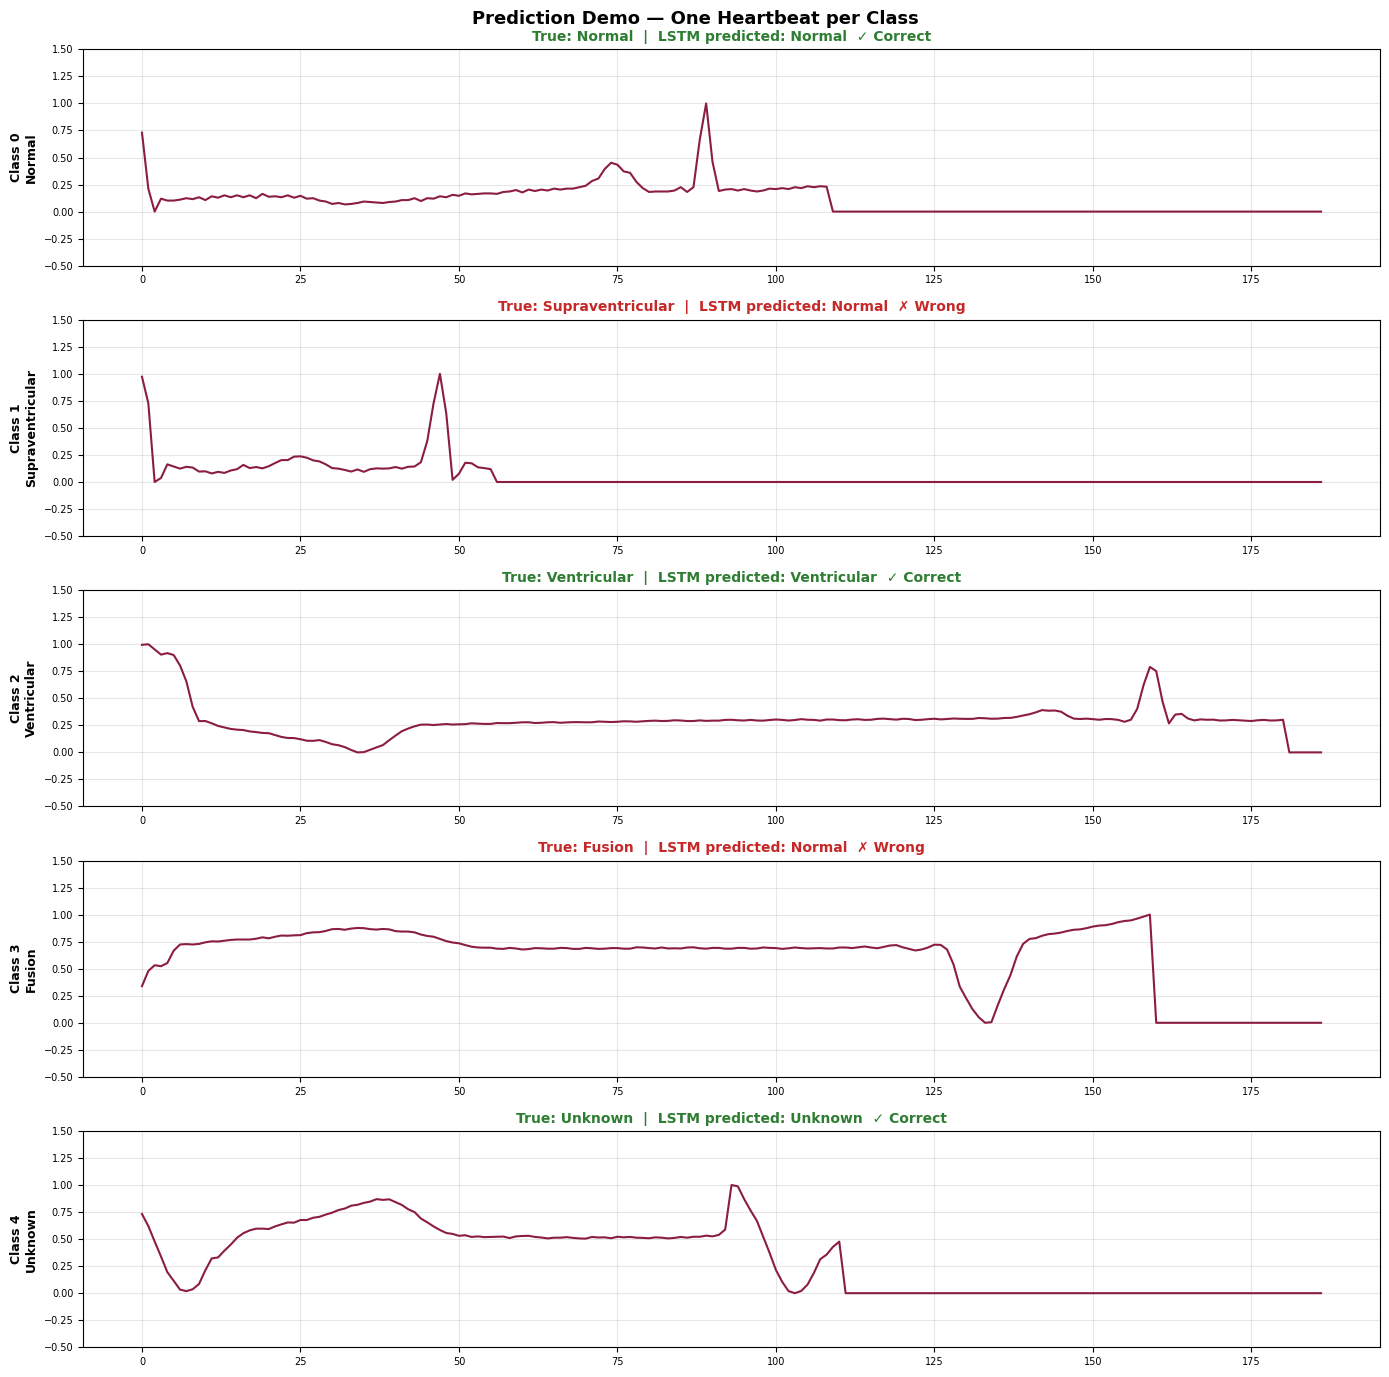

In [ ]:
# Visualize: signal + prediction label
fig, axes = plt.subplots(5, 1, figsize=(14, 14))
fig.suptitle("Prediction Demo — One Heartbeat per Class",
             fontsize=13, fontweight="bold")

for i in range(5):
    signal  = demo_signals[i, :, 0]
    true_c  = demo_labels[i]
    lstm_c  = pred_lstm_demo[i]
    correct = lstm_c == true_c
    color   = "#2E7D32" if correct else "#C62828"

    axes[i].plot(signal, color="#8B1E3F", linewidth=1.5)
    axes[i].set_ylabel(f"Class {i}\n{class_names[i]}",
                       fontsize=9, fontweight="bold")
    axes[i].set_ylim(-0.5, 1.5)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(
        f"True: {class_names[true_c]}  |  "
        f"LSTM predicted: {class_names[lstm_c]}  "
        f"{'✓ Correct' if correct else '✗ Wrong'}",
        fontsize=10, color=color, fontweight="bold"
    )
    axes[i].tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### What the Predictions Show

| True Class | RNN | LSTM |
|------------|-----|------|
| Normal | Normal ✓ | Normal ✓ |
| Supraventricular | Normal ✗ | Normal ✗ |
| Ventricular | Normal ✗ | Ventricular ✓ |
| Fusion | Normal ✗ | Normal ✗ |
| Unknown | Normal ✗ | Unknown ✓ |

The Plain RNN predicted "Normal" for every single heartbeat — confirming
the per-class results from Step 8.

The LSTM correctly identified 3 out of 5 samples. The two misses —
Supraventricular and Fusion — are the hardest classes in the dataset.
Supraventricular signals look visually similar to Normal, and Fusion
has only 162 training samples — too few for the model to learn
reliably. The LSTM confidence scores reflect this: on the Fusion
sample it assigned 93.4% probability to Normal, showing it was not
uncertain — it made a committed wrong prediction because it has not
seen enough Fusion examples to distinguish them.

The LSTM's correct predictions came with high confidence: 93.2% on
Normal, 93.4% on Ventricular, and 97.8% on Unknown — showing the
model is not guessing when it gets it right.

---

## Step 10 — Why Order-Awareness Helped

ECG signals are sequential by nature — each time step depends on what
came before it. A normal heartbeat follows a specific pattern that
unfolds over time: a P wave, then a sharp QRS complex, then a T wave.
Disruptions to this pattern — in timing, shape, or amplitude — are
what define arrhythmias.

A Dense Network would receive the same 187 values as an unordered list.
It has no way to know that value at step 83 follows value at step 82,
or that the QRS peak at step 80 is meaningful because of what came
before it. Shuffling the time steps would produce identical input to
a Dense Network — but a completely different and meaningless signal
to a cardiologist.

The LSTM processes the signal one step at a time, carrying a memory
of everything it has seen so far. By the time it reaches step 187,
its hidden state reflects the full shape of the heartbeat — not just
isolated values. This is what allowed it to reach 67.2% recall on
Ventricular beats and 87.4% on Unknown beats, while the Plain RNN —
which also processes steps sequentially but cannot retain long-range
memory — stayed near 0% on both classes.
Order-awareness was not just helpful here — it was the minimum requirement for the task to be solvable at all.

## Step 11 — Interactive Prediction Demo (Gradio)

### What is Gradio?

Gradio is a Python library that builds a simple web interface for ML models
in a few lines of code. Instead of running predictions manually in code,
the user can interact with the model directly through a browser.

Here I build a minimal interface that takes a heartbeat index from the
test set and shows the ECG signal alongside the LSTM's prediction and
confidence scores — the same prediction pipeline from Step 9, but
accessible without writing any code.

In [28]:
!pip install gradio -q

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

def predict_heartbeat(sample_index):
    idx = int(sample_index)
    signal = X_test_rnn[idx]
    true_label = int(y_test[idx])

    # LSTM prediction
    probs = lstm_model.predict(signal[np.newaxis], verbose=0)[0]
    pred_label = int(np.argmax(probs))

    # Plot ECG signal
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(signal[:, 0], color="#8B1E3F", linewidth=1.5)
    ax.set_title(
        f"True: {class_names[true_label]}  |  "
        f"LSTM Predicted: {class_names[pred_label]}  "
        f"{'✓ Correct' if pred_label == true_label else '✗ Wrong'}",
        fontsize=11,
        color="#2E7D32" if pred_label == true_label else "#C62828",
        fontweight="bold"
    )
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    # Confidence scores
    confidence = {class_names[i]: float(probs[i]) for i in range(5)}

    return fig, confidence

# Build Gradio interface
demo = gr.Interface(
    fn=predict_heartbeat,
    inputs=gr.Slider(
        minimum=0,
        maximum=len(X_test_rnn) - 1,
        step=1,
        value=0,
        label="Test Sample Index"
    ),
    outputs=[
        gr.Plot(label="ECG Signal"),
        gr.Label(label="LSTM Confidence Scores")
    ],
    title="ECG Heartbeat Classifier — LSTM",
    description="Select a heartbeat from the test set. The LSTM will classify it into one of 5 categories.",
    examples=[[0], [100], [500], [1000], [5000]]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e95d7cf84bc1dba5a1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Note on Prediction Accuracy

The Gradio interface shows the LSTM's raw prediction on individual samples.
As documented in Step 8, the model performs well on Normal (95.6%) and
Unknown (87.4%) beats, but struggles on minority classes — particularly
Fusion (35.2%) and Supraventricular (36.2%).

A wrong prediction on a single sample is expected and consistent with
the per-class recall results. The interface is useful for exploring model
behavior, not as a clinical tool.

---

## Summary

In this lab I built and compared two sequence models on the MIT-BIH
Arrhythmia Dataset — 87,554 ECG heartbeats across 5 classes.

| Step | What I Did |
|------|-----------|
| 1–3 | Loaded and explored the dataset — identified 82.8% class imbalance |
| 4–6 | Trained a Plain RNN baseline — confirmed vanishing gradient failure |
| 7 | Trained an LSTM with class weighting — two targeted improvements |
| 8 | Evaluated both models on the test set — compared per-class recall |
| 9 | Ran a single-heartbeat prediction demo — inspected confidence scores |
| 10 | Explained why order-awareness was necessary for this task |

### Final Results

| Metric | Plain RNN | LSTM |
|--------|-----------|------|
| Test Accuracy | 83.02% | **91.14%** |
| Test Loss | 0.6222 | **0.2949** |
| Ventricular Recall | 2.8% | **67.2%** |
| Unknown Recall | 0.0% | **87.4%** |
| Fusion Recall | 0.0% | **35.2%** |

### Key Takeaways

**Architecture matters:** the Plain RNN could not propagate gradients
through 187 time steps. The LSTM's gated memory solved this directly —
the Epoch 8 breakthrough in training was the moment long-range patterns
became accessible.

**Class weighting was necessary:** without it, any model trained on this
dataset will predict "Normal" for everything and score 83% accuracy
while missing every arrhythmia. The weights forced the model to treat
rare-class mistakes as costly.

**Order-awareness was the minimum requirement:** ECG signals carry their
diagnostic information in the shape and timing of the waveform across
187 time steps. A model that ignores order cannot distinguish arrhythmia
classes from normal beats — as the Plain RNN demonstrated completely.